# NB06 — K562 Case Studies

This notebook builds 1–2 convincing K562 case studies by comparing the canonical model against the strongest cell baseline.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install anndata scanpy torch pandas scikit-learn scipy matplotlib mygene

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00


In [16]:
import os, random, pickle
from dataclasses import dataclass

import anndata as ad
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import mygene

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

@dataclass
class CFG:
    base_dir: str = "/content/drive/MyDrive/ChemDFM"
    art_dir: str = "/content/drive/MyDrive/ChemDFM/canonical_q1/artifacts"
    ckpt_dir: str = "/content/drive/MyDrive/ChemDFM/checkpoints_nb01"
    data_path: str = "/content/drive/MyDrive/ChemDFM/data/sciplex_complete_middle_subset.h5ad"
    batch_size: int = 512
    control_name: str = "control"
    top_genes: int = 20
cfg = CFG()

OUT_DIR = f"{cfg.base_dir}/results_nb06_final"
os.makedirs(OUT_DIR, exist_ok=True)
print("ART_DIR exists:", os.path.exists(cfg.art_dir))
print("CKPT_DIR exists:", os.path.exists(cfg.ckpt_dir))

Using device: cpu
ART_DIR exists: True
CKPT_DIR exists: True


In [17]:
adata = ad.read_h5ad(cfg.data_path)
X = adata.X
if hasattr(X, "toarray"): X = X.toarray()
X = np.asarray(X, dtype=np.float32)

X_pca = np.load(f"{cfg.art_dir}/X_pca.npy")
with open(f"{cfg.art_dir}/pca_model.pkl", "rb") as f: pca = pickle.load(f)
with open(f"{cfg.art_dir}/ctrl_means_pca.pkl", "rb") as f: ctrl_means_pca = pickle.load(f)
with open(f"{cfg.art_dir}/ctrl_means_gene.pkl", "rb") as f: ctrl_means_gene = pickle.load(f)
with open(f"{cfg.art_dir}/drug_encoder.pkl", "rb") as f: drug_enc = pickle.load(f)
with open(f"{cfg.art_dir}/cell_encoder.pkl", "rb") as f: cell_enc = pickle.load(f)

obs = pd.read_csv(f"{cfg.art_dir}/obs_table.csv")
X0_pca = np.stack([ctrl_means_pca[c] for c in obs["cell_type"].astype(str).values]).astype(np.float32)
X0_gene = np.stack([ctrl_means_gene[c] for c in obs["cell_type"].astype(str).values]).astype(np.float32)

# gene mapping for readable case tables
if "gene_id" in adata.var.columns:
    raw_gene_names = adata.var["gene_id"].astype(str).values
elif "id" in adata.var.columns:
    raw_gene_names = adata.var["id"].astype(str).values
else:
    raw_gene_names = np.array([f"G{i}" for i in range(adata.n_vars)])

ensembl_ids = [str(g).split(".")[0] for g in raw_gene_names]
mg = mygene.MyGeneInfo()
query_res = mg.querymany(
    ensembl_ids,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True,
    verbose=False
)
ensembl_to_symbol = {}
if hasattr(query_res, "iterrows"):
    for idx, row in query_res.iterrows():
        if isinstance(idx, str):
            symbol = row.get("symbol", None)
            if pd.notna(symbol):
                ensembl_to_symbol[idx] = str(symbol).upper()
gene_symbols = [ensembl_to_symbol.get(g, str(g)) for g in ensembl_ids]

In [18]:
class DS(Dataset):
    def __init__(self, split):
        mask = (obs["_split3"].values == split) & (obs["condition"].astype(str).str.lower().values != cfg.control_name)
        self.idxs = np.where(mask)[0]
    def __len__(self): return len(self.idxs)
    def __getitem__(self, i):
        idx = self.idxs[i]; row = obs.iloc[idx]
        return {
            "idx": int(idx),
            "x0": torch.tensor(X0_pca[idx], dtype=torch.float32),
            "drug_idx": torch.tensor(int(row["drug_idx"]), dtype=torch.long),
            "cell_idx": torch.tensor(int(row["cell_idx"]), dtype=torch.long),
            "dose": torch.tensor([np.log1p(max(float(row["dose"]),0.0))], dtype=torch.float32),
            "condition": str(row["condition"]),
            "cell_type": str(row["cell_type"]),
        }

ood_loader = DataLoader(DS("ood"), batch_size=cfg.batch_size, shuffle=False)
print("OOD perturbed samples:", len(ood_loader.dataset))

OOD perturbed samples: 10559


In [19]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        layers=[]; prev=in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(dropout)]
            prev=h
        layers.append(nn.Linear(prev,out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

class StructuredDoseEncoder(nn.Module):
    def __init__(self, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,16), nn.ReLU(), nn.Linear(16,out_dim))
    def forward(self,dose): return self.net(dose)

class ResidualDoseResponseModel(nn.Module):
    def __init__(self, latent_dim, n_drugs, n_cells, emb_dim=32, hidden=256, dose_hidden=32, dropout=0.1):
        super().__init__()
        self.drug_emb = nn.Embedding(n_drugs, emb_dim)
        self.cell_emb = nn.Embedding(n_cells, emb_dim)
        self.dose_enc = StructuredDoseEncoder(dose_hidden)
        self.ctrl_enc = MLP(latent_dim, [hidden, hidden], hidden, dropout)
        self.delta_head = MLP(hidden + emb_dim + emb_dim + dose_hidden, [hidden, hidden], latent_dim, dropout)
    def forward(self, x0, drug_idx, cell_idx, dose):
        z = torch.cat([self.ctrl_enc(x0), self.drug_emb(drug_idx), self.cell_emb(cell_idx), self.dose_enc(dose)], dim=1)
        delta_hat = self.delta_head(z)
        return delta_hat, x0 + delta_hat

model = ResidualDoseResponseModel(X_pca.shape[1], len(drug_enc.classes_), len(cell_enc.classes_)).to(DEVICE)
CKPT_PATH = f"{cfg.ckpt_dir}/best_residual_only.pt"
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print("Loaded:", CKPT_PATH)

Loaded: /content/drive/MyDrive/ChemDFM/checkpoints_nb01/best_residual_only.pt


In [20]:
# strongest K562 baseline in gene space
train_mask = (obs["_split3"].values == "train") & (obs["condition"].astype(str).str.lower().values != cfg.control_name)
cell_mean_delta_gene = {}
for cell in sorted(obs["cell_type"].astype(str).unique()):
    m = train_mask & (obs["cell_type"].astype(str).values == cell)
    cell_mean_delta_gene[cell] = (X[m] - X0_gene[m]).mean(axis=0)

def top_gene_names(delta_vec, topn=20):
    idx = np.argsort(-np.abs(delta_vec))[:topn]
    out=[]; seen=set()
    for i in idx:
        g = str(gene_symbols[i]).strip()
        if g and g.lower() != "nan" and g not in seen:
            out.append(g); seen.add(g)
    return out[:topn]

@torch.no_grad()
def infer_k562_cases():
    rows=[]; gene_rows=[]
    for batch in ood_loader:
        idxs=np.array(batch["idx"], dtype=int)
        x0=batch["x0"].to(DEVICE); drug_idx=batch["drug_idx"].to(DEVICE); cell_idx=batch["cell_idx"].to(DEVICE); dose=batch["dose"].to(DEVICE)
        _, x_hat = model(x0, drug_idx, cell_idx, dose)
        pred_gene = pca.inverse_transform(x_hat.cpu().numpy()).astype(np.float32)

        for j, idx in enumerate(idxs):
            row = obs.iloc[idx]
            if str(row["cell_type"]) != "K562":
                continue

            true_gene = X[idx]
            x0_gene = X0_gene[idx]
            pred = pred_gene[j]
            base = x0_gene + cell_mean_delta_gene["K562"]

            idx_top = np.argsort(-np.abs(true_gene - x0_gene))[:50]
            r2_model = r2_score(true_gene[idx_top], pred[idx_top])
            r2_base = r2_score(true_gene[idx_top], base[idx_top])
            gain = float(r2_model - r2_base)
            model_better = int(gain > 0)

            rows.append({
                "idx": int(idx),
                "condition": str(row["condition"]),
                "dose": float(row["dose"]),
                "r2_top50_model": float(r2_model),
                "r2_top50_baseline": float(r2_base),
                "gain_over_baseline": gain,
                "model_better": model_better,
            })

            true_delta = true_gene - x0_gene
            pred_delta = pred - x0_gene
            base_delta = base - x0_gene

            gene_rows.append({
                "idx": int(idx),
                "condition": str(row["condition"]),
                "dose": float(row["dose"]),
                "top_true_genes": ", ".join(top_gene_names(true_delta, cfg.top_genes)),
                "top_pred_genes": ", ".join(top_gene_names(pred_delta, cfg.top_genes)),
                "top_baseline_genes": ", ".join(top_gene_names(base_delta, cfg.top_genes)),
            })
    return pd.DataFrame(rows), pd.DataFrame(gene_rows)

k562_cases, k562_genes = infer_k562_cases()
print("K562 OOD single-sample rows:", len(k562_cases))

K562 OOD single-sample rows: 2641


In [21]:
# Grouped summary
grouped = k562_cases.groupby(["condition","dose"], as_index=False).agg(
    r2_top50_model=("r2_top50_model","mean"),
    r2_top50_baseline=("r2_top50_baseline","mean"),
    gain_over_baseline=("gain_over_baseline","mean"),
    model_better_rate=("model_better","mean"),
    n_samples=("idx","count")
)

best_cases = grouped.sort_values(["gain_over_baseline","model_better_rate"], ascending=[False,False]).head(10)
worst_cases = grouped.sort_values(["gain_over_baseline","model_better_rate"], ascending=[True,True]).head(10)

print("Best K562 grouped cases:")
print(best_cases)
print("\\nWorst K562 grouped cases:")
print(worst_cases)

summary = pd.DataFrame([{
    "n_grouped_cases": len(grouped),
    "fraction_groups_model_better": float((grouped["gain_over_baseline"] > 0).mean()),
    "mean_gain_over_baseline": float(grouped["gain_over_baseline"].mean()),
    "median_gain_over_baseline": float(grouped["gain_over_baseline"].median()),
}])
print("\\nK562 summary:")
print(summary)

grouped.to_csv(f"{OUT_DIR}/k562_grouped_cases.csv", index=False)
best_cases.to_csv(f"{OUT_DIR}/best_k562_cases.csv", index=False)
worst_cases.to_csv(f"{OUT_DIR}/worst_k562_cases.csv", index=False)
summary.to_csv(f"{OUT_DIR}/k562_summary.csv", index=False)

Best K562 grouped cases:
       condition     dose  r2_top50_model  r2_top50_baseline  \
15   Pracinostat  10000.0       -3.916456          -4.216011   
5     Crizotinib  10000.0       -4.633874          -4.833661   
16       SNS-314  10000.0       -5.613845          -5.778824   
2    Azacitidine  10000.0       -5.407312          -5.464572   
8        Fasudil  10000.0       -6.333362          -6.382971   
1   Alvespimycin  10000.0       -5.877339          -5.912394   
10          IOX2  10000.0       -5.873203          -5.885989   
6     Entacapone  10000.0       -6.205392          -6.216199   
17       XAV-939  10000.0       -5.603918          -5.611812   
4      Cediranib  10000.0       -6.007239          -5.998200   

    gain_over_baseline  model_better_rate  n_samples  
15            0.299555           0.953846         65  
5             0.199787           0.786885         61  
16            0.164979           0.946565        131  
2             0.057261           0.705882        1

In [22]:
# readable gene tables for top 3 best + top 3 challenging cases
selected_pairs = set(tuple(x) for x in pd.concat([
    best_cases[["condition","dose"]].head(3),
    worst_cases[["condition","dose"]].head(3),
]).values)

case_gene_table = (
    k562_genes[k562_genes[["condition","dose"]].apply(tuple, axis=1).isin(selected_pairs)]
    .drop_duplicates(subset=["condition","dose"])
    .reset_index(drop=True)
)

print("Case gene table:")
print(case_gene_table.head(10))
case_gene_table.to_csv(f"{OUT_DIR}/k562_case_gene_table.csv", index=False)

Case gene table:
      idx    condition     dose  \
0  265694      SNS-314  10000.0   
1  265874  Momelotinib  10000.0   
2  265945     AG-14361  10000.0   
3  266001   Crizotinib  10000.0   
4  266241  Pracinostat  10000.0   
5  266697   Luminespib  10000.0   

                                      top_true_genes  \
0  CCDC26, TBC1D9B, HBG1, PRKCB, MAPK1, RPS5, ARI...   
1  SNX13, TXNRD1, GPATCH8, IGF2BP2, ITFG1, LINC01...   
2  CFLAR, LY86-AS1, SLC25A21, PTPRB, JRKL-AS1, LI...   
3  IGFL2-AS1, BNIP3L, KAT6A, ZMYM2, CTSD, CRPPA, ...   
4  ENSG00000259560, GFPT1, MALT1, G6PD, ENSG00000...   
5  ENSG00000259560, CPED1, HSPD1, PTH2R, EPB41, D...   

                                      top_pred_genes  \
0  EPB41, SLC25A37, MBNL1, ARID4B, P4HA1, GAPDH, ...   
1  LINC00534, STXBP5, PRKCB, PRKCA, MACF1, MAML2,...   
2  PRKCA, FADS1, MACF1, LINC00534, STXBP5, MAML2,...   
3  EPB41, LINC00534, SLC25A37, STXBP5, PRKCA, HBG...   
4  FADS1, LINC00534, PRKCB, STXBP5, ZFPM2, LOC105...   
5  LINC0

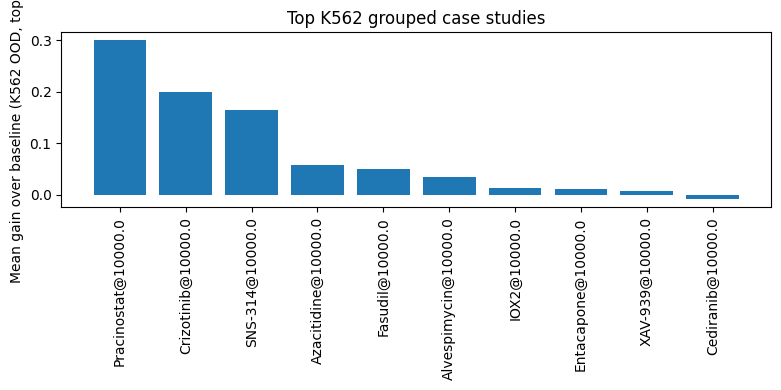

In [23]:
# plot grouped gains
fig, ax = plt.subplots(figsize=(8,4))
tmp = best_cases.copy()
tmp["label"] = tmp["condition"].astype(str) + "@" + tmp["dose"].astype(str)
ax.bar(tmp["label"], tmp["gain_over_baseline"])
ax.set_ylabel("Mean gain over baseline (K562 OOD, top50 R²)")
ax.set_title("Top K562 grouped case studies")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/figure_k562_best_case_gains.png", dpi=220)
plt.show()